# Лабораторная работа 7. Полносвязные нейронные сети (FCNN). Решение задачи регрессии

## Загрузка данных и понижение размерности

In [65]:


import matplotlib.pyplot as plt
import optuna
from matplotlib.lines import lineStyles
from sklearn.compose import ColumnTransformer

from sklearn.feature_selection import VarianceThreshold

import pandas as pd
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearnex.model_selection import train_test_split


In [66]:
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("datasets/air.csv", index_col = 0)

X, y = data.drop("CO(GT)", axis=1), data["CO(GT)"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

selector_vt = VarianceThreshold(threshold=0.015)
X_vt = selector_vt.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vt, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

print(f"Исходные признаки: {X.columns.tolist()}, количество: {len(X.columns.tolist())}")
print(f"Признаки после понижения размерности: {X.columns[selector_vt.get_support()].tolist()},"
      f" количество: {len(X.columns[selector_vt.get_support()].tolist())}")

## FCNN (MLP) из библиотеки Scikit-learn

In [67]:
columns = [
    'Regressor', 'Search strategy',
    'Train_R2', 'Train_MSE', 'Train_MAE',
    'Test_R2', 'Test_MSE', 'Test_MAE', 'Epochs', 'Solver'
]
table = pd.DataFrame(columns=columns)
table

,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver


In [68]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


def input_into_table(name, search_name, model, X_train, y_train, X_test, y_test):

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    new_row = {
        'Regressor': name,
        'Search strategy': search_name,
        'Train_R2': round(r2_score(y_train, train_pred), 2),
        'Train_MSE': round(mean_squared_error(y_train, train_pred), 4),
        'Train_MAE': round(mean_absolute_error(y_train, train_pred), 4),
        'Test_R2': round(r2_score(y_test, test_pred), 2),
        'Test_MSE': round(mean_squared_error(y_test, test_pred), 4),
        'Test_MAE': round(mean_absolute_error(y_test, test_pred), 4),
        'Epochs': model.n_iter_,
        'Solver': model.solver
    }

    table.loc[len(table)] = new_row

### Optuna

In [69]:
def objective(trial):
    params = {
        'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes',
                                                        [(100,), (50, 50), (100, 50), (100, 100, 100)]),

        'solver': trial.suggest_categorical('solver', ['adam', 'sgd', 'lbfgs']),

        'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),

        'alpha': trial.suggest_float('alpha', 1e-5, 1e-2, log=True),

        'learning_rate': trial.suggest_categorical('learning_rate', ['constant', 'adaptive']),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True)
    }

    regressor = MLPRegressor(**params, random_state=15, max_iter=1000)

    score = cross_val_score(regressor, X_train, y_train, cv=5, n_jobs=-1, scoring="r2").mean()

    return score

study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=15)

print(f"Лучшие параметры: {study.best_params}")

[I 2026-05-11 18:36:17,539] A new study created in memory with name: no-name-a322a578-32ff-4c44-989b-b815966fdf45
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  optuna_warn(message)
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50, 50) which is of type tuple.
  optuna_warn(message)
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100, 50) which is of type tuple.
  optuna_warn(messa

Лучшие параметры: {'hidden_layer_sizes': (100, 50), 'solver': 'lbfgs', 'activation': 'relu', 'alpha': 0.0002056587573133198, 'learning_rate': 'adaptive', 'learning_rate_init': 0.006094190485535515}


In [70]:
model = MLPRegressor(**study.best_params, random_state=15)
model.fit(X_train, y_train)
input_into_table("MLPRegressor", "Optuna", model, X_train, y_train, X_test, y_test)
table

C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver
0,MLPRegressor,Optuna,0.93,0.0007,0.0191,0.91,0.001,0.0213,200,lbfgs


In [71]:
n_layers = len(model.coefs_)

print(f"Количество скрытых слоев: {model.n_layers_ - 2}")
print(f"Архитектура слоев (нейроны):")
for i, weights in enumerate(model.coefs_):
    print(f" Связи между слоем {i} и {i+1}: {weights.shape[0]} -> {weights.shape[1]}")


Количество скрытых слоев: 2
Архитектура слоев (нейроны):
 Связи между слоем 0 и 1: 15 -> 100
 Связи между слоем 1 и 2: 100 -> 50
 Связи между слоем 2 и 3: 50 -> 1


In [72]:
import seaborn as sns
def make_graphic(model, name):
    fig, axes = plt.subplots(1, 2)

    sns.kdeplot(y_train, ax=axes[0], label="Истинные значения")
    sns.kdeplot(model.predict(X_train), ax=axes[0], label="Предсказанные значения", linestyle="--", color="red")
    axes[0].set_title("Train")

    sns.kdeplot(y_test, ax=axes[1], label="Истинные значения")
    sns.kdeplot(model.predict(X_test), ax=axes[1], label="Предсказанные значения", linestyle="--", color="red")
    axes[1].set_title("Test")

    axes[0].grid(True, alpha=0.3)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(name)

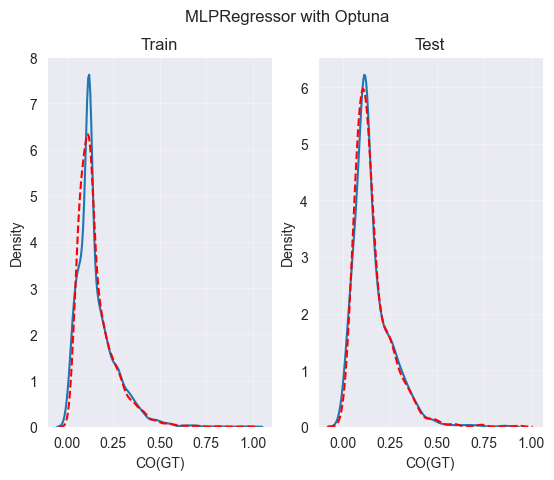

In [73]:

make_graphic(model, "MLPRegressor with Optuna")

In [74]:
print(f"Архитектура сети: {model.hidden_layer_sizes}")

print(f"Количество слоев: {model.n_layers_}")

print(f"Количество весов (коэффициентов): {[coef.shape for coef in model.coefs_]}")

Архитектура сети: (100, 50)
Количество слоев: 4
Количество весов (коэффициентов): [(15, 100), (100, 50), (50, 1)]


### RandomizeSearchCV

In [76]:
param_dist = {
    'hidden_layer_sizes': [(100,), (50, 50), (100, 50), (100, 100, 100)],
    'solver': ['adam', 'sgd', 'lbfgs'],
    'activation': ['relu', 'tanh'],
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2],
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
}

mlp = MLPRegressor(max_iter=1000)

rs = RandomizedSearchCV(estimator=mlp,
                        param_distributions=param_dist,
                        n_jobs=-1,
                        cv=3,
                        scoring="r2",
                        verbose=3)

rs.fit(X_train, y_train)
input_into_table("MLPRegressor", "RandomizedSearch", rs.best_estimator_, X_train, y_train, X_test, y_test)
table

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver
0,MLPRegressor,Optuna,0.93,0.0007,0.0191,0.91,0.001,0.0213,200,lbfgs
1,MLPRegressor,RandomizedSearch,0.92,0.0008,0.0199,0.90,0.001,0.0221,94,lbfgs


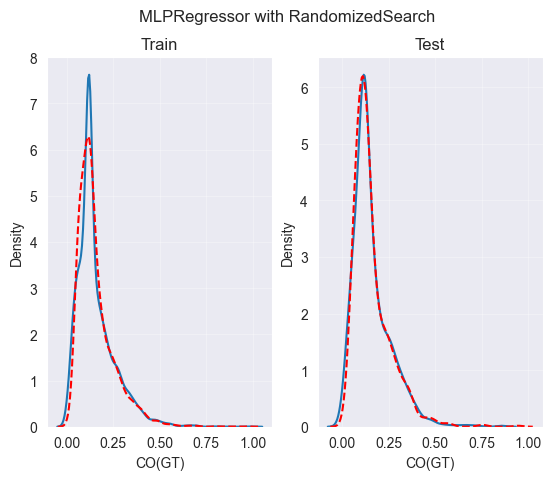

In [77]:
make_graphic(rs.best_estimator_, "MLPRegressor with RandomizedSearch")

In [78]:
print(f"Архитектура сети: {rs.best_estimator_.hidden_layer_sizes}")

print(f"Количество слоев: {rs.best_estimator_.n_layers_}")

print(f"Количество весов (коэффициентов): {[coef.shape for coef in rs.best_estimator_.coefs_]}")

Архитектура сети: (100, 100, 100)
Количество слоев: 5
Количество весов (коэффициентов): [(15, 100), (100, 100), (100, 100), (100, 1)]


### Hyperport

In [79]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import numpy as np

layers = [(100,), (50, 50), (100, 50), (100, 100, 100)]
solvers = ['adam', 'sgd', 'lbfgs']
activations = ['relu', 'tanh']
learning_rates = ['constant', 'adaptive']

space = {
    'hidden_layer_sizes': hp.choice('hidden_layer_sizes', layers),
    'solver': hp.choice('solver', solvers),
    'activation': hp.choice('activation', activations),
    'alpha': hp.loguniform('alpha', np.log(1e-5), np.log(1e-2)),
    'learning_rate': hp.choice('learning_rate', learning_rates),
}

def objective(params):
    model = MLPRegressor(**params, max_iter=2000, random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='r2').mean()
    return {'loss': -score, 'status': STATUS_OK}

trials = Trials()
best_indices = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=15, trials=trials)

best_params = {
    'hidden_layer_sizes': layers[best_indices['hidden_layer_sizes']],
    'solver': solvers[best_indices['solver']],
    'activation': activations[best_indices['activation']],
    'alpha': best_indices['alpha'],
    'learning_rate': learning_rates[best_indices['learning_rate']],
}


best_model_hyperopt = MLPRegressor(**best_params, max_iter=2000, random_state=42).fit(X_train, y_train)
input_into_table("MLPRegressor", "Hyperopt", best_model_hyperopt, X_train, y_train, X_test, y_test)

print("Лучшие параметры Hyperopt:", best_params)

100%|██████████| 15/15 [00:58<00:00,  3.89s/trial, best loss: -0.880471838090897] 
Лучшие параметры Hyperopt: {'hidden_layer_sizes': (100, 50), 'solver': 'lbfgs', 'activation': 'relu', 'alpha': 0.0010608074305493169, 'learning_rate': 'constant'}


In [81]:
table

,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver
0,MLPRegressor,Optuna,0.93,0.0007,0.0191,0.91,0.001,0.0213,200,lbfgs
1,MLPRegressor,RandomizedSearch,0.92,0.0008,0.0199,0.90,0.001,0.0221,94,lbfgs
2,MLPRegressor,Hyperopt,0.92,0.0008,0.0205,0.91,0.001,0.0219,141,lbfgs


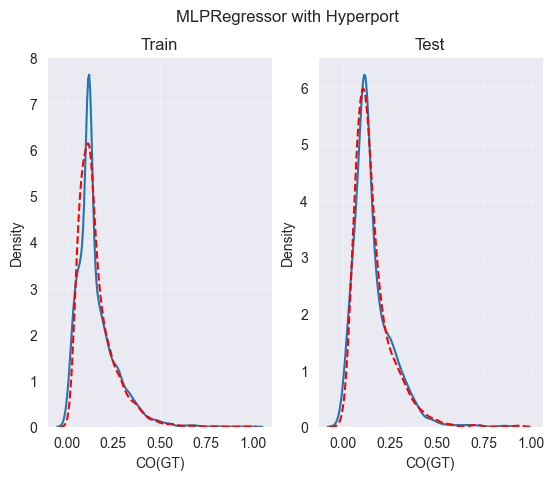

In [82]:
make_graphic(best_model_hyperopt, "MLPRegressor with Hyperport")

In [83]:
print(f"Архитектура сети: {best_model_hyperopt.hidden_layer_sizes}")

print(f"Количество слоев: {best_model_hyperopt.n_layers_}")

print(f"Количество весов (коэффициентов): {[coef.shape for coef in best_model_hyperopt.coefs_]}")

Архитектура сети: (100, 50)
Количество слоев: 4
Количество весов (коэффициентов): [(15, 100), (100, 50), (50, 1)]


## Keras

In [84]:
import keras
def input_into_table_keras(name, search_name, model, X_train, y_train, X_test, y_test, history):

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    new_row = {
        'Regressor': name,
        'Search strategy': search_name,
        'Train_R2': round(r2_score(y_train, train_pred), 2),
        'Train_MSE': round(mean_squared_error(y_train, train_pred), 4),
        'Train_MAE': round(mean_absolute_error(y_train, train_pred), 4),
        'Test_R2': round(r2_score(y_test, test_pred), 2),
        'Test_MSE': round(mean_squared_error(y_test, test_pred), 4),
        'Test_MAE': round(mean_absolute_error(y_test, test_pred), 4),
        'Epochs': len(history.history['loss']),
        'Solver': model.optimizer.__class__.__name__
    }

    table.loc[len(table)] = new_row

optimizers_dict = {
    "adam": keras.optimizers.Adam,
    "sgd": keras.optimizers.SGD,
    "rmsprop": keras.optimizers.RMSprop,
}

### Optuna

In [85]:
import numpy as np
import pandas as pd
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import KFold

def objective(trial):
    n_layers = trial.suggest_int("n_layers", 1, 5)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    activation = trial.suggest_categorical("activation", ["relu", "tanh", "elu"])
    opt_name = trial.suggest_categorical("optimizer", list(optimizers_dict.keys()))
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in kf.split(X_train):
        X_t, X_v = X_train[train_idx], X_train[val_idx]
        y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = keras.Sequential()
        model.add(layers.Input(shape=(X_t.shape[1],)))

        for i in range(n_layers):
            num_hidden = trial.suggest_int(f"n_units_l{i}", 16, 512, log=True)
            model.add(layers.Dense(num_hidden, activation=activation))
            dropout_rate = trial.suggest_float(f"dropout_l{i}", 0.0, 0.3)
            model.add(layers.Dropout(dropout_rate))

        model.add(layers.Dense(1, activation="linear"))

        optimizer = optimizers_dict[opt_name](learning_rate=learning_rate)
        model.compile(
            optimizer=optimizer,
            loss="mean_squared_error",
            metrics=["mean_absolute_error"]
        )

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )

        model.fit(
            X_t, y_t,
            validation_data=(X_v, y_v),
            epochs=100,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0
        )

        y_pred = model.predict(X_v, verbose=0)
        score = r2_score(y_v, y_pred)
        scores.append(score)

    return np.mean(scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print(f"Лучшая ошибка (MAE): {study.best_value}")
print(f"Параметры: {study.best_params}")



[I 2026-05-11 18:40:20,781] A new study created in memory with name: no-name-7d3ff7c7-b7dc-4e4b-aa21-23f17e160831
[I 2026-05-11 18:41:26,615] Trial 0 finished with value: 0.6198364797510524 and parameters: {'n_layers': 2, 'learning_rate': 0.00022671072157805683, 'activation': 'tanh', 'optimizer': 'sgd', 'batch_size': 32, 'n_units_l0': 119, 'dropout_l0': 0.14929562008007227, 'n_units_l1': 31, 'dropout_l1': 0.12025983443130894}. Best is trial 0 with value: 0.6198364797510524.
[I 2026-05-11 18:41:52,221] Trial 1 finished with value: 0.8375822099239342 and parameters: {'n_layers': 3, 'learning_rate': 0.0032250260152405313, 'activation': 'tanh', 'optimizer': 'adam', 'batch_size': 32, 'n_units_l0': 47, 'dropout_l0': 0.19990316555976695, 'n_units_l1': 104, 'dropout_l1': 0.15691917813480066, 'n_units_l2': 221, 'dropout_l2': 0.05731809296140038}. Best is trial 1 with value: 0.8375822099239342.
[I 2026-05-11 18:42:43,955] Trial 2 finished with value: 0.8205871146101696 and parameters: {'n_layers

Лучшая ошибка (MAE): 0.8422931791419881
Параметры: {'n_layers': 3, 'learning_rate': 0.00024968049688924325, 'activation': 'relu', 'optimizer': 'adam', 'batch_size': 32, 'n_units_l0': 30, 'dropout_l0': 0.16985295481399196, 'n_units_l1': 91, 'dropout_l1': 0.07606581052367099, 'n_units_l2': 446, 'dropout_l2': 0.022398290895935258}


In [86]:
import keras
params = study.best_params
model = keras.Sequential()
model.add(layers.Input(shape=(X_train.shape[1],)))


for i in range(params["n_layers"]):
    model.add(layers.Dense(
        params[f"n_units_l{i}"],
        activation=params["activation"]
    ))
    if f"dropout_l{i}" in params:
        model.add(layers.Dropout(params[f"dropout_l{i}"]))

model.add(layers.Dense(1, activation="linear"))

model.compile(
    optimizer=optimizers_dict[params["optimizer"]](learning_rate=params["learning_rate"]),
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=study.best_params["batch_size"],
    verbose=2
)

Epoch 1/100
222/222 - 1s - 5ms/step - loss: 0.0067 - mae: 0.0605 - val_loss: 0.0025 - val_mae: 0.0373
Epoch 2/100
222/222 - 0s - 1ms/step - loss: 0.0039 - mae: 0.0470 - val_loss: 0.0031 - val_mae: 0.0412
Epoch 3/100
222/222 - 0s - 1ms/step - loss: 0.0032 - mae: 0.0425 - val_loss: 0.0022 - val_mae: 0.0349
Epoch 4/100
222/222 - 0s - 1ms/step - loss: 0.0030 - mae: 0.0405 - val_loss: 0.0026 - val_mae: 0.0374
Epoch 5/100
222/222 - 0s - 1ms/step - loss: 0.0028 - mae: 0.0392 - val_loss: 0.0018 - val_mae: 0.0310
Epoch 6/100
222/222 - 0s - 2ms/step - loss: 0.0025 - mae: 0.0366 - val_loss: 0.0023 - val_mae: 0.0355
Epoch 7/100
222/222 - 0s - 1ms/step - loss: 0.0023 - mae: 0.0354 - val_loss: 0.0019 - val_mae: 0.0320
Epoch 8/100
222/222 - 0s - 1ms/step - loss: 0.0022 - mae: 0.0349 - val_loss: 0.0025 - val_mae: 0.0373
Epoch 9/100
222/222 - 0s - 2ms/step - loss: 0.0021 - mae: 0.0334 - val_loss: 0.0018 - val_mae: 0.0313
Epoch 10/100
222/222 - 0s - 2ms/step - loss: 0.0020 - mae: 0.0326 - val_loss: 0.00

In [87]:
model.summary()

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_120 (Dense)               │ (None, 30)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_90 (Dropout)            │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_121 (Dense)               │ (None, 91)             │         2,821 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_91 (Dropout)            │ (None, 91)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_122 (Dense)               │ (None, 446)            │        41,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_92 (Dropout)            │ (None, 446)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_123 (Dense)               │ (None, 1)              │           447 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,342 (524.78 KB)

 Trainable params: 44,780 (174.92 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 89,562 (349.86 KB)

In [88]:
input_into_table_keras("FCNN (Keras)", "Optuna", model, X_train, y_train, X_test, y_test, history)

222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 657us/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


Text(0, 0.5, 'Loss (MSE)')

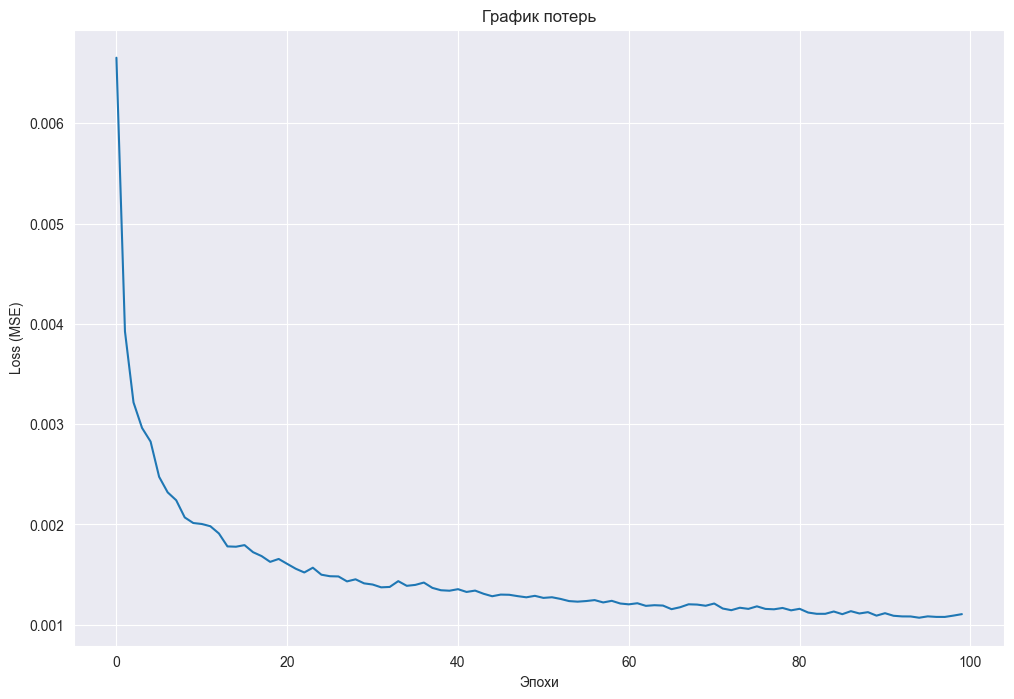

In [90]:
plt.figure(figsize=(12, 8))
plt.plot(history.history['loss'])
plt.title("График потерь")
plt.xlabel("Эпохи")
plt.ylabel("Loss (MSE)")

In [92]:
table

,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver
0,MLPRegressor,Optuna,0.93,0.0007,0.0191,0.91,0.0010,0.0213,200,lbfgs
1,MLPRegressor,RandomizedSearch,0.92,0.0008,0.0199,0.90,0.0010,0.0221,94,lbfgs
2,MLPRegressor,Hyperopt,0.92,0.0008,0.0205,0.91,0.0010,0.0219,141,lbfgs
3,FCNN (Keras),Optuna,0.88,0.0013,0.0253,0.86,0.0015,0.0265,100,Adam


222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


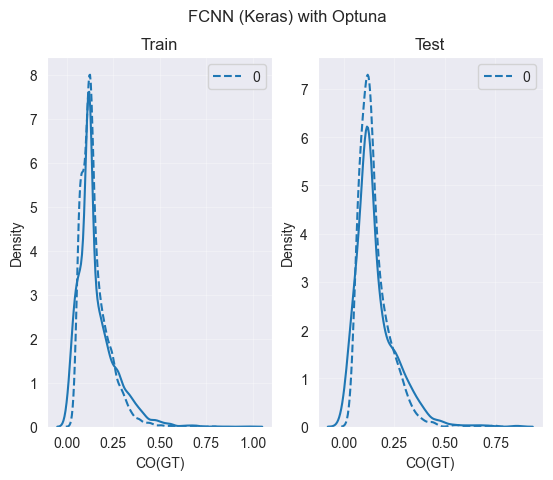

In [91]:
make_graphic(model, "FCNN (Keras) with Optuna")

### KerasTuner

In [93]:
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))

    for i in range(hp.Int("n_layers", 1, 5)):
        model.add(layers.Dense(
            units=hp.Int(f"units_{i}", min_value=32, max_value=512, step=32),
            activation=hp.Choice("activation", ["relu", "tanh", "elu"])
        ))
        if hp.Boolean("dropout"):
            model.add(layers.Dropout(0.2))

    model.add(layers.Dense(1, activation="linear"))

    lr = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")


    optimizer_name = hp.Choice("optimizer", list(optimizers_dict.keys()))

    optimizer = optimizers_dict[optimizer_name](learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )
    return model


In [95]:
import keras_tuner as kt
import keras
from keras import layers
tuner = kt.BayesianOptimization(
    build_model,
    objective="val_mae",
    max_trials=20
)


tuner.search(X_train, y_train, epochs=50, validation_data=(X_val, y_val), verbose=2)

best_model = tuner.get_best_models(num_models=1)[0]
best_params = tuner.get_best_hyperparameters(num_trials=1)[0]


Trial 20 Complete [00h 00m 27s]
val_mae: 0.03231045603752136

Best val_mae So Far: 0.018627621233463287
Total elapsed time: 00h 06m 39s


C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [96]:
history = best_model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_val, y_val),
    verbose=2
)

input_into_table_keras(
    name="FCNN (Keras)",
    search_name="KerasTuner (Bayesian)",
    model=best_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    history=history
)


Epoch 1/50
222/222 - 1s - 5ms/step - loss: 3.0124e-04 - mae: 0.0124 - val_loss: 8.4842e-04 - val_mae: 0.0189
Epoch 2/50
222/222 - 0s - 1ms/step - loss: 2.9707e-04 - mae: 0.0123 - val_loss: 8.1291e-04 - val_mae: 0.0184
Epoch 3/50
222/222 - 0s - 1ms/step - loss: 2.8424e-04 - mae: 0.0119 - val_loss: 8.7404e-04 - val_mae: 0.0194
Epoch 4/50
222/222 - 0s - 2ms/step - loss: 2.6349e-04 - mae: 0.0116 - val_loss: 7.8926e-04 - val_mae: 0.0179
Epoch 5/50
222/222 - 0s - 1ms/step - loss: 2.5390e-04 - mae: 0.0114 - val_loss: 9.6423e-04 - val_mae: 0.0197
Epoch 6/50
222/222 - 0s - 1ms/step - loss: 2.7196e-04 - mae: 0.0117 - val_loss: 7.8216e-04 - val_mae: 0.0186
Epoch 7/50
222/222 - 0s - 1ms/step - loss: 2.3878e-04 - mae: 0.0109 - val_loss: 8.0605e-04 - val_mae: 0.0183
Epoch 8/50
222/222 - 0s - 1ms/step - loss: 2.3970e-04 - mae: 0.0109 - val_loss: 8.2799e-04 - val_mae: 0.0188
Epoch 9/50
222/222 - 0s - 1ms/step - loss: 2.3113e-04 - mae: 0.0108 - val_loss: 8.5926e-04 - val_mae: 0.0186
Epoch 10/50
222/222

Text(0, 0.5, 'Loss (MSE)')

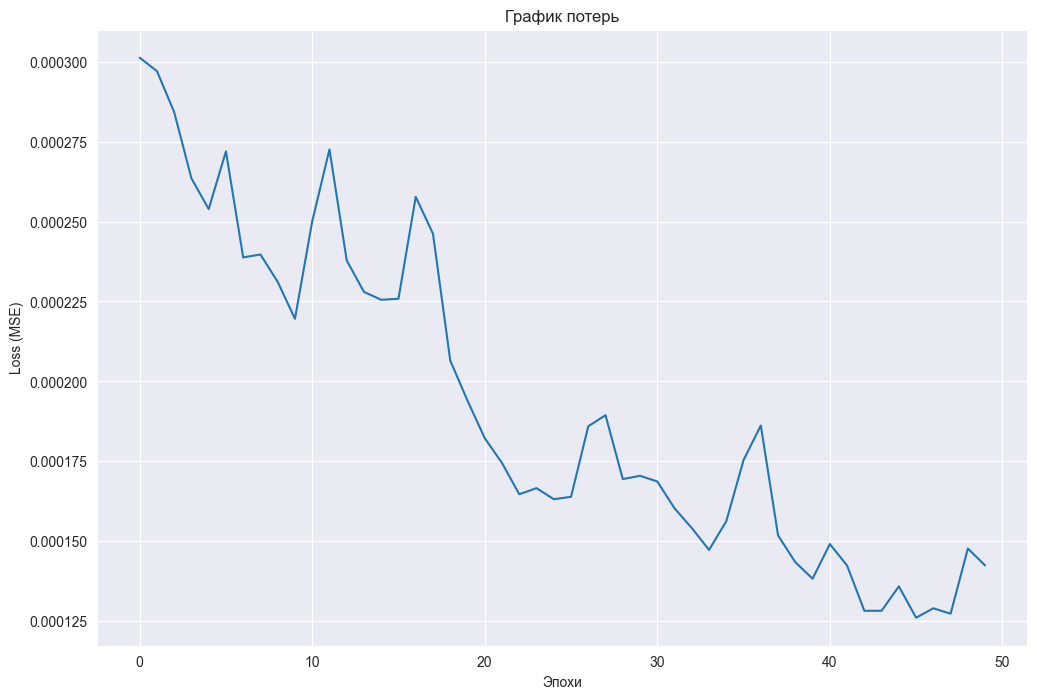

In [97]:
plt.figure(figsize=(12, 8))
plt.plot(history.history['loss'])
plt.title("График потерь")
plt.xlabel("Эпохи")
plt.ylabel("Loss (MSE)")

222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 616us/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


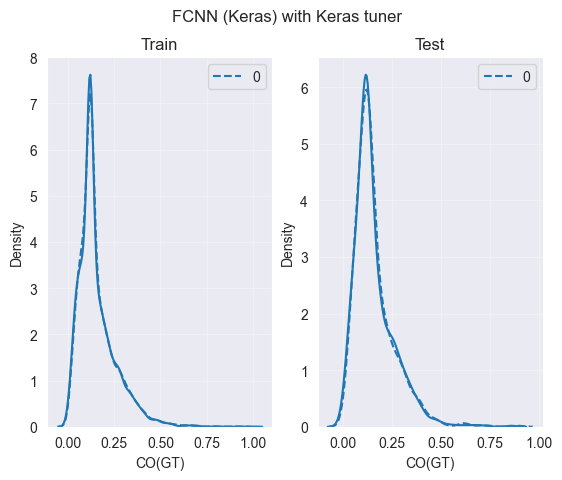

In [98]:
make_graphic(best_model, "FCNN (Keras) with Keras tuner")

In [99]:
table[table["Search strategy"] == "KerasTuner (Bayesian)"]

,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver
4,FCNN (Keras),KerasTuner (Bayesian),0.99,0.0001,0.0074,0.94,0.0006,0.0162,50,Adam


In [100]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 192)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 320)            │        61,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 96)             │        30,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 296,357 (1.13 MB)

 Trainable params: 98,785 (385.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 197,572 (771.77 KB)

### RayTune

In [102]:
y_train = np.array(y_train)

In [103]:
from ray import tune
from sklearn.model_selection import KFold
import tensorflow as tf
from tensorflow.keras import layers, Sequential
import numpy as np

def train_model_ray(config):

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    fold_results = []

    opt_map = {
        "adam": tf.keras.optimizers.Adam,
        "sgd": tf.keras.optimizers.SGD,
        "rmsprop": tf.keras.optimizers.RMSprop
    }

    for train_idx, val_idx in kf.split(X_train):
        X_t, X_v = X_train[train_idx], X_train[val_idx]
        y_t, y_v = y_train[train_idx], y_train[val_idx]

        model = Sequential()
        model.add(layers.Input(shape=(X_t.shape[1],)))

        for i in range(config["n_layers"]):
            model.add(layers.Dense(
                units=config[f"units_{i}"],
                activation=config["activation"]
            ))
            if config["dropout"]:
                model.add(layers.Dropout(0.2))

        model.add(layers.Dense(1, activation="linear"))

        optimizer = opt_map[config["optimizer"]](learning_rate=config["lr"])
        model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

        history = model.fit(
            X_t, y_t,
            epochs=30,
            batch_size=32,
            validation_data=(X_v, y_v),
            verbose=0
        )

        fold_results.append(min(history.history["val_mae"]))

    mean_mae = float(np.mean(fold_results))
    tune.report({"val_mae": mean_mae})


search_space = {
    "n_layers": tune.randint(1, 6),
    "activation": tune.choice(["relu", "tanh", "elu"]),
    "dropout": tune.choice([True, False]),
    "lr": tune.loguniform(1e-4, 1e-2),
    "optimizer": tune.choice(list(optimizers_dict.keys())),
}


for i in range(5):
    search_space[f"units_{i}"] = tune.qrandint(32, 512, 32)


tuner = tune.Tuner(
    train_model_ray,
    param_space=search_space,
    tune_config=tune.TuneConfig(
        metric="val_mae",
        mode="min",
        num_samples=20
    )
)

results = tuner.fit()
print("Лучшие параметры:", results.get_best_result().config)


2026-05-11 19:07:17,310	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-11_19-06-01_566030_15640\artifacts\2026-05-11_19-07-17\train_model_ray_2026-05-11_19-07-17\driver_artifacts\train_model_ray_56048_00000_0_activation=relu,dropout=True,lr=0.0002,n_layers=3,optimizer=adam,units_0=320,units_1=288,units_2=128_2026-05-11_19-07-17
2026-05-11 19:07:17,458	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-11_19-06-01_566030_15640\artifacts\2026-05-11_19-07-17\train_model_ray_2026-05-11_19-07-17\driver_artifacts\train_model_ray_56048_00000_0_activation=relu,dropout=True,lr=0.0002,n_layers=3,optimizer=adam,units_0=320,units_1=288,units_2=128_2026-05-11_19-07-17
2026-05-11 19:

2026-05-11 19:07:32,464	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-11_19-06-01_566030_15640\artifacts\2026-05-11_19-07-17\train_model_ray_2026-05-11_19-07-17\driver_artifacts\train_model_ray_56048_00001_1_activation=relu,dropout=True,lr=0.0097,n_layers=2,optimizer=adam,units_0=384,units_1=512,units_2=384_2026-05-11_19-07-17
2026-05-11 19:07:32,525	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-11_19-06-01_566030_15640\artifacts\2026-05-11_19-07-17\train_model_ray_2026-05-11_19-07-17\driver_artifacts\train_model_ray_56048_00002_2_activation=elu,dropout=True,lr=0.0026,n_layers=4,optimizer=adam,units_0=160,units_1=128,units_2=160,_2026-05-11_19-07-17
2026-05-11 19:

Лучшие параметры: {'n_layers': 2, 'activation': 'relu', 'dropout': True, 'lr': 0.009738478611630984, 'optimizer': 'adam', 'units_0': 384, 'units_1': 512, 'units_2': 384, 'units_3': 384, 'units_4': 32}


In [104]:
config = results.get_best_result().config
model = keras.Sequential()
model.add(layers.Input(shape=(X_train.shape[1],)))

for i in range(config["n_layers"]):
    model.add(layers.Dense(
        units=config[f"units_{i}"],
        activation=config["activation"]
    ))
    if config["dropout"]:
        model.add(layers.Dropout(0.2))

model.add(layers.Dense(1, activation="linear"))


optimizer = optimizers_dict[config["optimizer"]](learning_rate=config["lr"])
model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])


history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

input_into_table_keras(
    name="FCNN (Keras)",
    search_name="Ray Tune",
    model=model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    history=history
)


Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7887 - mae: 0.2713 - val_loss: 0.0018 - val_mae: 0.0294
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0029 - mae: 0.0378 - val_loss: 0.0021 - val_mae: 0.0338
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0024 - mae: 0.0343 - val_loss: 0.0016 - val_mae: 0.0266
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0022 - mae: 0.0327 - val_loss: 0.0015 - val_mae: 0.0263
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0021 - mae: 0.0320 - val_loss: 0.0016 - val_mae: 0.0268
Epoch 6/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0021 - mae: 0.0318 - val_loss: 0.0017 - val_mae: 0.0300
Epoch 7/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0021 - mae: 0.0315 - val_loss: 0.0015 - val_mae: 0.0263
Epoch 8/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0021 - mae: 0.0321 - val_loss: 0.0015 - val_mae: 0.0269
Epoch 9/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

In [105]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 384)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 611,333 (2.33 MB)

 Trainable params: 203,777 (796.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 407,556 (1.55 MB)

In [106]:
table[table["Search strategy"] == "Ray Tune"]

,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver
5,FCNN (Keras),Ray Tune,0.76,0.0026,0.0369,0.75,0.0025,0.0358,50,Adam


Text(0, 0.5, 'Loss (MSE)')

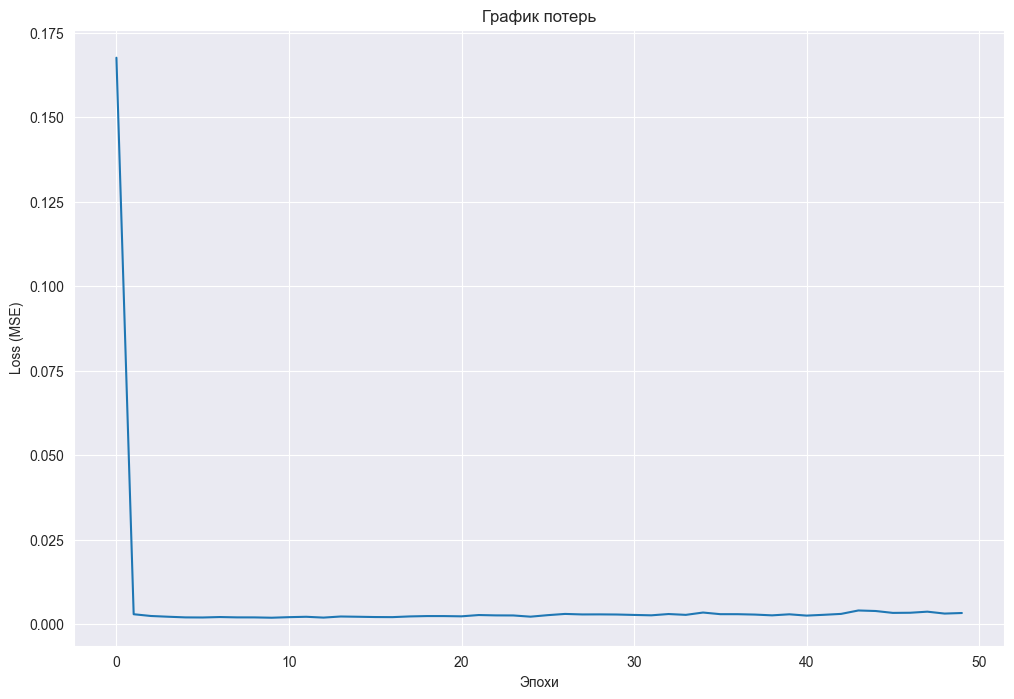

In [107]:
plt.figure(figsize=(12, 8))
plt.plot(history.history['loss'])
plt.title("График потерь")
plt.xlabel("Эпохи")
plt.ylabel("Loss (MSE)")

222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


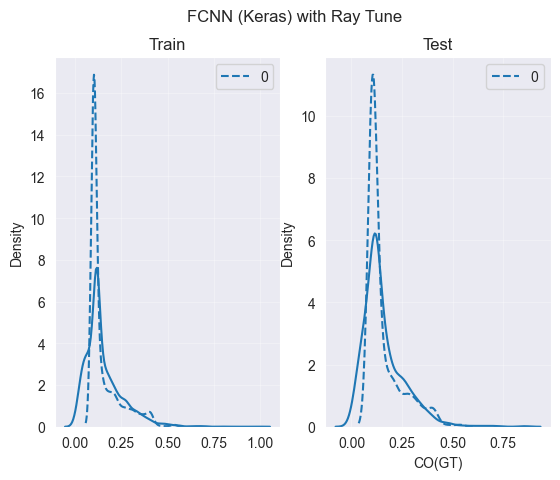

In [108]:
make_graphic(model, "FCNN (Keras) with Ray Tune")

In [109]:
table

,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver
0,MLPRegressor,Optuna,0.93,0.0007,0.0191,0.91,0.0010,0.0213,200,lbfgs
1,MLPRegressor,RandomizedSearch,0.92,0.0008,0.0199,0.90,0.0010,0.0221,94,lbfgs
2,MLPRegressor,Hyperopt,0.92,0.0008,0.0205,0.91,0.0010,0.0219,141,lbfgs
3,FCNN (Keras),Optuna,0.88,0.0013,0.0253,0.86,0.0015,0.0265,100,Adam
4,FCNN (Keras),KerasTuner (Bayesian),0.99,0.0001,0.0074,0.94,0.0006,0.0162,50,Adam
5,FCNN (Keras),Ray Tune,0.76,0.0026,0.0369,0.75,0.0025,0.0358,50,Adam


## Вывод

In [110]:
table

,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver
0,MLPRegressor,Optuna,0.93,0.0007,0.0191,0.91,0.0010,0.0213,200,lbfgs
1,MLPRegressor,RandomizedSearch,0.92,0.0008,0.0199,0.90,0.0010,0.0221,94,lbfgs
2,MLPRegressor,Hyperopt,0.92,0.0008,0.0205,0.91,0.0010,0.0219,141,lbfgs
3,FCNN (Keras),Optuna,0.88,0.0013,0.0253,0.86,0.0015,0.0265,100,Adam
4,FCNN (Keras),KerasTuner (Bayesian),0.99,0.0001,0.0074,0.94,0.0006,0.0162,50,Adam
5,FCNN (Keras),Ray Tune,0.76,0.0026,0.0369,0.75,0.0025,0.0358,50,Adam


In [119]:
best_model

<Sequential name=sequential, built=True>

In [123]:
sample_data = np.array([[
    1.25,
    0.3,
    0.2,
    0.4,
    0.4,
    0.6,
    0.5,
    0.7,
    0.5,
    0.3,
    0.1,
    3,
    1,
    12,
    2004
]], dtype='float32')

prediction = best_model.predict(sample_data)
print(f"Результат предсказания: {prediction[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Результат предсказания: [16.037085]
